<img src="logo-UNSAM.png" style="float: right;" width="300" alt="Logo">

# <center>Análisis y Procesamiento de Señales</center>
<hr>

## <center>**TS4**: "Primeras nociones de estimación espectral"</center>

<br><br>

### <center>1er Cuatrimestre - 2026</center>
### <center>**Alumno:** D'Alesio Alejo</center>


<br>

Inicialmente creamos una señal senoidal con ruido, que tendrá la seguiente forma:



\begin{align}
    x(k) &= a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n) \\[6pt]
    a_0 &= \sqrt{2} \\[6pt]
    \Omega_1 &= \Omega_0 + f_r \cdot \frac{2\pi}{N} \\[6pt]
    \Omega_0 &= \frac{\pi}{2}
\end{align}

 donde $f_r$ es una variable aleatoria con distribución de probabilidad:

\begin{align}
    f_r &\sim \mathcal{U}(-2,\, 2) \\[6pt]
    n_a &\sim \mathcal{N}(0,\, \sigma^2)
\end{align}

Considero una cantidad de 200 realizaciones (muestras tomadas de $f_r$) de 1000 muestras para cada experimento. Para el caso del ruido, tengo en cuenta la potencia de ruido como $P_r = \frac{P_s}{10^{\frac{SNR_{dB}}{10}}}$

Debido a que trabajamos con registros de longitud finita ($N=1000$), la señal se ve afectada por el truncamiento temporal. Para mitigar los efectos del spectral leakage y mejorar la precisión de las estimaciones, aplicamos un proceso de ventaneo. Matemáticamente, esto consiste en multiplicar la señal en el tiempo por una función de ventana $w[n]$, lo que equivale a una convolución en el dominio de la frecuencia entre el espectro de la señal y la transformada de la ventana. En este trabajo, comparamos cuatro funciones de ventana: Rectangular, Flat-top, Blackman-Harris y Hamming. Para cada una, se implementaron dos estimadores estadísticos:
* **Estimador de Amplitud ($\hat{a}_0$):** Calculado a partir del módulo de la FFT en la frecuencia de interés ($\Omega_0$).
    $$\hat{a}_0 = |X_w^i(\Omega_0)|$$
<br>

* **Estimador de Frecuencia ($\hat{\Omega}_1$):** Obtenido mediante la búsqueda del máximo valor (*argmax*) en el espectro de magnitud.
    $$\hat{\Omega}_1^i = \arg \max_f \{ |X_w^i(\Omega)| \}$$
<br>

Para evaluar el desempeño de cada ventana frente al ruido y al desplazamiento de frecuencia, calculamos el sesgo ($s_a$) y la varianza ($v_a$) de los estimadores. El objetivo es determinar qué ventana ofrece el mejor compromiso entre resolución espectral y exactitud en la medición de amplitud.

* **Sesgo del Estimador ($s_a$):** Representa la exactitud del estimador. Es la diferencia entre el valor esperado (promedio) de nuestras estimaciones y el valor real del parámetro $a_0$.
    $$s_a = E\{\hat{a}_0\} - a_0$$
<br>

* **Varianza del Estimador ($v_a$):** Mide la precisión o dispersión de los resultados. Indica qué tan sensible es el estimador al ruido en cada una de las realizaciones.
    $$v_a = var\{\hat{a}_0\} = E\{(\hat{a}_0 - E\{\hat{a}_0\})^2\}$$
<br>

## Caso de Señal con SNR 10 dB

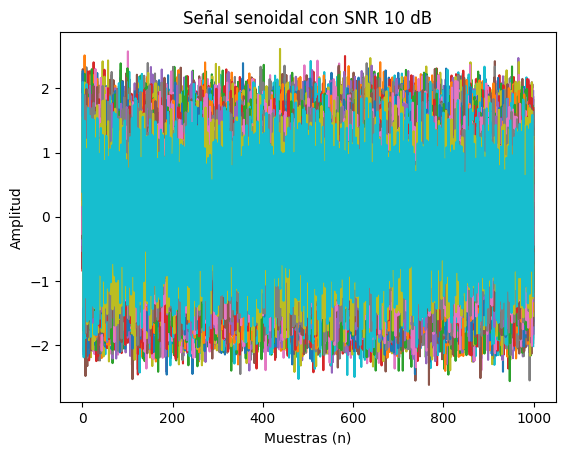

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import flattop
from scipy.signal.windows import blackmanharris
from scipy.signal.windows import hamming

#DECLARACION DE VARIABLES 

N = 1000 #Cantidad de muestras (filas)
R = 200 #cantidad de realizaciones (Columna)
w0 = N/4 #frecuencia de w0 en mitad de nyquist
a0 = np.sqrt(2) #amplitud, elijo raiz(2) para normalizarla
Ps = 1
mu = 0
SNR_dB = 10  # es el SNR deseado, ej 10
Pr = Ps / (10**(SNR_dB/10)) #potencia del ruido 

#genero una lista de valores random de -2 a 2

fr = np.random.uniform(low=-2, high=2,size =  200) 

#genero el vector de n de 1000 elementos

n = np.arange(N) #Genero de un array de muestras con una cantidad de N-1 muestras
array_n = n.reshape(N,1)
#frecuencia

w = (2 * np.pi/N) * (w0 + fr)
 
#%% CREO SENO CON RUIDO

SNR_dB = 10  # es el SNR deseado, ej 10
Pr = Ps / (10**(SNR_dB/10)) #potencia del ruido 

#ruido
sigma = np.sqrt(Pr) #es la que uso en ruido, sigma² es potencia de ruido
ruido = np.random.normal(mu, sigma, size = (N,R))

#Funcion seno

x_n= a0*np.sin((w*array_n)) 

#Le sumo el ruido

x_r =  x_n + ruido

plt.figure()
plt.plot(x_r);         
plt.title("Señal senoidal con SNR 10 dB")
plt.xlabel("Muestras (n)")
plt.ylabel("Amplitud")
plt.show()

### Análisis de Estimadores a SNR 10 dB

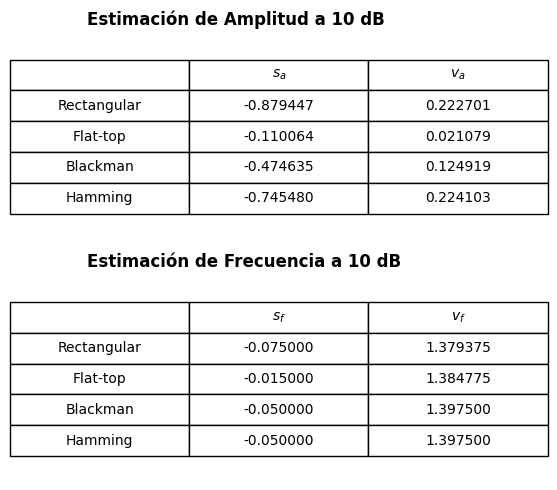

In [17]:
#%% -------------- VENTANEO ------------------

#RECTANGULAR


#Estimador de Energia

#Sesgo

# 1. Identificamos el bin exacto de nuestra frecuencia fundamental w0
bin_w0 = int(N/4) # Esto da 250, sino daria 250.0


# 2. Extraemos el valor complejo de la FFT en ese bin para las 200 realizaciones
# XXr tiene forma (1000, 200), así que tomamos la fila 250 y todas las columnas (:)
X_w0 = XXr[bin_w0, :]  #el resultado es una vector de 200 numeros

#cada elemento de X_w0 es la FFT de en w0 de cada experimento

# 3. Calculamos la amplitud estimada para cada una de las 200 realizaciones

a_r_estimado = (np.abs(X_w0) * 2) / N #multiplico por 2 para recuperar la energia dividida en dos mitades
                                    # divido por N para escalar bien
# 4. Calculamos el valor esperado (promedio de las 200 estimaciones)
E_a = np.mean(a_r_estimado)

# 5. Calculamos el sesgo
sesgo = E_a - a0


#Varianza

varianza_a = np.var(a_r_estimado)


#Estimador de Frecuencia

# Sesgo

# 1. Nos quedamos con la magnitud de la mitad positiva del espectro (Nyquist)
# para asegurarnos de no agarrar el pico de las frecuencias negativas por error.
magnitud_espectro = np.abs(XXr[:N//2 + 1, :])

# 2. Encontramos el índice (el bin 'k') donde está el máximo de energía
# np.argmax te devuelve la posición del valor más grande. 
# axis=0 lo hace para cada una de las 200 columnas (realizaciones) a la vez.
f_r_estimado = np.argmax(magnitud_espectro, axis=0)
# k_estimado es ahora un vector de 200 números (ej: [249, 251, 250, 248...])

# 3. Calculamos el valor esperado (promedio de los 200 índices estimados)
E_f_r = np.mean(f_r_estimado)

# 4. Calculamos el sesgo (Diferencia entre el promedio estimado y la frecuencia real w0)
sesgo_f_r = E_f_r - w0

# Varianza
varianza_f_r = np.var(f_r_estimado)

#FLATTOP

# Generamos la ventana de tamaño N (1000 muestras)
# sym=True es el comportamiento por defecto.

ventana_ft = flattop(N, sym=True)

# La ventana es un array 1D de (1000,). Para multiplicarla por la matriz x_r 
# que es de (1000, 200), necesitamos darle forma de columna (1000, 1)
ventana_ft_col = ventana_ft.reshape(N, 1)

# Aplicamos el ventaneo multiplicando la señal por la ventana en el tiempo
x_r_ft = x_r * ventana_ft_col

# Calculamos la nueva FFT sobre la señal ventaneada
XXr_ft = np.fft.fft(x_r_ft, n=N, axis=0)

# ---  ESTIMADOR DE AMPLITUD (CON FLAT TOP) ---

#sesgo

# Extraemos el bin de interés
X_w0_ft = XXr_ft[bin_w0, :]

# Reemplazamos "N" por la suma de la ventana para compensar la atenuación
S1_ft = np.sum(ventana_ft)
a_estimado_ft = (np.abs(X_w0_ft) * 2) / S1_ft #Lo dividimos por la suma de los valores de la ventana

E_a_ft = np.mean(a_estimado_ft)
sesgo_a_ft = E_a_ft - a0

#varianza
varianza_a_ft = np.var(a_estimado_ft)

# ---  ESTIMADOR DE FRECUENCIA (CON FLAT TOP) ---

#sesgo

magnitud_espectro_ft = np.abs(XXr_ft[:N//2 + 1, :])
f_estimado_ft = np.argmax(magnitud_espectro_ft, axis=0)


E_k_ft = np.mean(f_estimado_ft)
sesgo_k_ft = E_k_ft - w0

#varianza

varianza_k_ft = np.var(f_estimado_ft)


#BLACHMANHARRIS


# Generamos la ventana de tamaño N (1000 muestras)
ventana_bh = blackmanharris(N, sym=True)

# La transformamos en columna para multiplicarla por la matriz de 200 realizaciones
ventana_bh_col = ventana_bh.reshape(N, 1)

# Aplicamos la ventana a la señal en el tiempo
x_r_bh = x_r * ventana_bh_col

# Calculamos la FFT de la señal ventaneada
XXr_bh = np.fft.fft(x_r_bh, n=N, axis=0)

# --- 2. ESTIMADOR DE AMPLITUD (CON BLACKMAN-HARRIS) ---

# Extraemos el bin exacto de w0 (250)

#sesgo

X_w0_bh = XXr_bh[bin_w0, :]

# Escalamos usando la suma de los valores de la ventana Blackman-Harris
S1_bh = np.sum(ventana_bh)
a_estimado_bh = (np.abs(X_w0_bh) * 2) / S1_bh


E_a_bh = np.mean(a_estimado_bh)
sesgo_a_bh = E_a_bh - a0

#varianza

varianza_a_bh = np.var(a_estimado_bh)

# --- 3. ESTIMADOR DE FRECUENCIA (CON BLACKMAN-HARRIS) ---

# Nos quedamos con la mitad del espectro
magnitud_espectro_bh = np.abs(XXr_bh[:N//2 + 1, :])

# Buscamos el bin con mayor energía
f_estimado_bh = np.argmax(magnitud_espectro_bh, axis=0)


E_k_bh = np.mean(f_estimado_bh)
sesgo_k_bh = E_k_bh - w0

#varianza

varianza_k_bh = np.var(f_estimado_bh)

#HAMMING

# Generamos la ventana de tamaño N (1000 muestras)
# M=N, sym=True es el comportamiento por defecto
ventana_hm = hamming(N, sym=True)

# La transformamos en columna
ventana_hm_col = ventana_hm.reshape(N, 1)

# Aplicamos la ventana a la señal en el tiempo
x_r_hm = x_r * ventana_hm_col

# Calculamos la FFT de la señal ventaneada
XXr_hm = np.fft.fft(x_r_hm, n=N, axis=0)


# --- 2. ESTIMADOR DE AMPLITUD (CON HAMMING) ---

#sesgo

# Extraemos el bin exacto de w0 (250)
X_w0_hm = XXr_hm[bin_w0, :]

# Escalamos usando la suma de los valores de la ventana Hamming
S1_hm = np.sum(ventana_hm)
a_estimado_hm = (np.abs(X_w0_hm) * 2) / S1_hm


E_a_hm = np.mean(a_estimado_hm)
sesgo_a_hm = E_a_hm - a0

#varianza

varianza_a_hm = np.var(a_estimado_hm)

# --- 3. ESTIMADOR DE FRECUENCIA (CON HAMMING) ---

#sesgo

# Nos quedamos con la mitad del espectro
magnitud_espectro_hm = np.abs(XXr_hm[:N//2 + 1, :])

# Buscamos el bin con mayor energía
f_estimado_hm = np.argmax(magnitud_espectro_hm, axis=0)

# Cálculos estadísticos
E_f_hm = np.mean(f_estimado_hm)
sesgo_f_hm = E_f_hm - w0

#varianza
varianza_f_hm = np.var(f_estimado_hm)


# ── Datos Amplitud ──────────────────────────────────────────────────────────
datos_amplitud = [
    ["Rectangular", f"{sesgo:.6f}",       f"{varianza_a:.6f}"],
    ["Flat-top",    f"{sesgo_a_ft:.6f}",  f"{varianza_a_ft:.6f}"],
    ["Blackman",    f"{sesgo_a_bh:.6f}",  f"{varianza_a_bh:.6f}"],
    ["Hamming",     f"{sesgo_a_hm:.6f}",  f"{varianza_a_hm:.6f}"],
]

# ── Datos Frecuencia ────────────────────────────────────────────────────────
datos_frecuencia = [
    ["Rectangular", f"{sesgo_f_r:.6f}",  f"{varianza_f_r:.6f}"],
    ["Flat-top",    f"{sesgo_k_ft:.6f}", f"{varianza_k_ft:.6f}"],
    ["Blackman",    f"{sesgo_k_bh:.6f}", f"{varianza_k_bh:.6f}"],
    ["Hamming",     f"{sesgo_f_hm:.6f}", f"{varianza_f_hm:.6f}"],
]

# ── Figura ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5))

for ax in (ax1, ax2):
    ax.axis("off")

col_labels1 = ["", r"$s_a$", r"$v_a$"]

# Tabla Amplitud
ax1.set_title("Estimación de Amplitud a 10 dB", fontweight="bold", loc="left", pad=8)
tabla1 = ax1.table(
    cellText=datos_amplitud,
    colLabels=col_labels1,
    loc="center",
    cellLoc="center",
)
tabla1.auto_set_font_size(False)
tabla1.set_fontsize(10)
tabla1.scale(1.4, 1.6)

col_labels2 = ["", r"$s_f$", r"$v_f$"]
# Tabla Frecuencia
ax2.set_title("Estimación de Frecuencia a 10 dB", fontweight="bold", loc="left", pad=8)
tabla2 = ax2.table(
    cellText=datos_frecuencia,
    colLabels=col_labels2,
    loc="center",
    cellLoc="center",
)
tabla2.auto_set_font_size(False)
tabla2.set_fontsize(10)
tabla2.scale(1.4, 1.6)

plt.tight_layout()
plt.show();

En primera instancia, se observa que en las estimaciones de frecuencia, todos los sesgos resultaron cercanos a 0. Esto indica que, bajo estas condiciones de ruido, todas las ventanas funcionan como estimadores insesgados para la frecuencia fundamental, centrando sus resultados en el bin real $w_0$.Sin embargo, para el caso de las estimaciones de amplitud, se observa un sesgo negativo significativo, especialmente en las ventanas Rectangular ($s_a \approx -0.88$) y Hamming ($s_a \approx -0.74$). Esto significa que el valor esperado de la amplitud es notablemente inferior al valor real $a_0 =\sqrt{2} \approx 1.44$.

Al observar la varianza de la amplitud ($v_a$), se destaca la ventana Flat-top con el valor más bajo ($v_a \approx 0.023$). Esto indica que no solo es la ventana más exacta (menor sesgo), sino también la más precisa, ya que sus estimaciones son muy consistentes entre sí a pesar del ruido y el desplazamiento de frecuencia. En contraste, las ventanas Rectangular y Hamming presentan varianzas mucho más altas ($\approx 0.22$ y $0.25$ respectivamente), lo que refleja una gran dispersión en los resultados debido a su alta sensibilidad al desfasaje espectral.
    En cuanto a la varianza de la frecuencia ($v_f$), los valores son significativamente más altos en todas las ventanas, situándose en el orden de $1.38$ a $1.41$. Esta mayor dispersión se debe a que el error en la detección del bin máximo está dominado por el componente aleatorio $f_r$ introducido en la señal original (el cual varía uniformemente entre -2 y 2), sumado al ruido térmico del canal ($SNR = 10 \text{ dB}$)

## Caso de Señal con SNR 3 dB

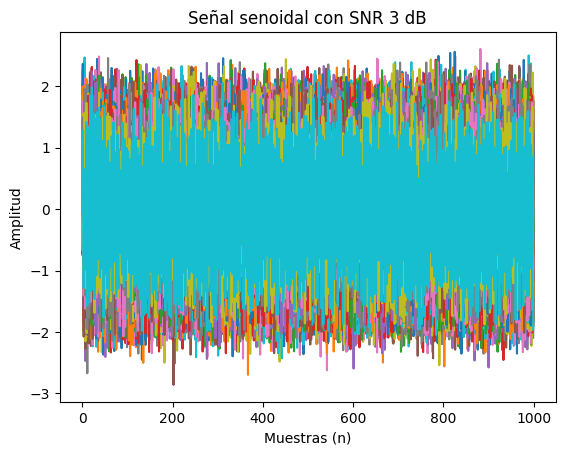

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import flattop
from scipy.signal.windows import blackmanharris
from scipy.signal.windows import hamming

#DECLARACION DE VARIABLES 

N = 1000 #Cantidad de muestras (filas)
R = 200 #cantidad de realizaciones (Columna)
w0 = N/4 #frecuencia de w0 en mitad de nyquist
a0 = np.sqrt(2) #amplitud, elijo raiz(2) para normalizarla
Ps = 1
mu = 0
SNR_dB = 3  # es el SNR deseado
Pr = Ps / (10**(SNR_dB/10)) #potencia del ruido 

#genero una lista de valores random de -2 a 2

fr = np.random.uniform(low=-2, high=2,size =  200) 

#genero el vector de n de 1000 elementos

n = np.arange(N) #Genero de un array de muestras con una cantidad de N-1 muestras
array_n = n.reshape(N,1)
#frecuencia

w = (2 * np.pi/N) * (w0 + fr)
 
#%% CREO SENO CON RUIDO

SNR_dB = 10  # es el SNR deseado, ej 10
Pr = Ps / (10**(SNR_dB/10)) #potencia del ruido 

#ruido
sigma = np.sqrt(Pr) #es la que uso en ruido, sigma² es potencia de ruido
ruido = np.random.normal(mu, sigma, size = (N,R))

#Funcion seno

x_n= a0*np.sin((w*array_n)) 

#Le sumo el ruido

x_r =  x_n + ruido

plt.figure()
plt.plot(x_r);         
plt.title("Señal senoidal con SNR 3 dB")
plt.xlabel("Muestras (n)")
plt.ylabel("Amplitud")
plt.show()

### Análisis de Estimadores a SNR 3 dB

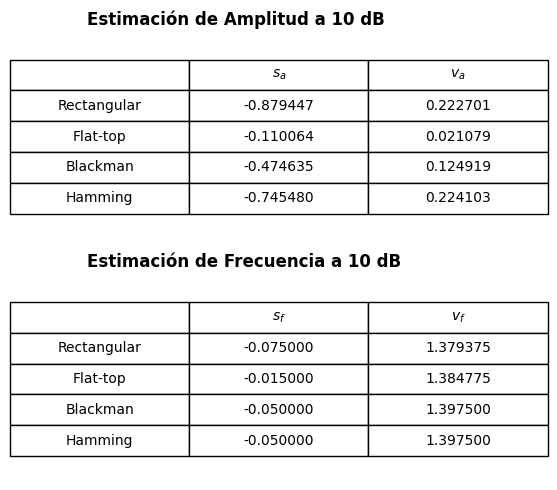

In [18]:
#%% -------------- VENTANEO ------------------

#RECTANGULAR


#Estimador de Energia

#Sesgo

# 1. Identificamos el bin exacto de nuestra frecuencia fundamental w0
bin_w0 = int(N/4) # Esto da 250, sino daria 250.0


# 2. Extraemos el valor complejo de la FFT en ese bin para las 200 realizaciones
# XXr tiene forma (1000, 200), así que tomamos la fila 250 y todas las columnas (:)
X_w0 = XXr[bin_w0, :]  #el resultado es una vector de 200 numeros

#cada elemento de X_w0 es la FFT de en w0 de cada experimento

# 3. Calculamos la amplitud estimada para cada una de las 200 realizaciones

a_r_estimado = (np.abs(X_w0) * 2) / N #multiplico por 2 para recuperar la energia dividida en dos mitades
                                    # divido por N para escalar bien
# 4. Calculamos el valor esperado (promedio de las 200 estimaciones)
E_a = np.mean(a_r_estimado)

# 5. Calculamos el sesgo
sesgo = E_a - a0


#Varianza

varianza_a = np.var(a_r_estimado)


#Estimador de Frecuencia

# Sesgo

# 1. Nos quedamos con la magnitud de la mitad positiva del espectro (Nyquist)
# para asegurarnos de no agarrar el pico de las frecuencias negativas por error.
magnitud_espectro = np.abs(XXr[:N//2 + 1, :])

# 2. Encontramos el índice (el bin 'k') donde está el máximo de energía
# np.argmax te devuelve la posición del valor más grande. 
# axis=0 lo hace para cada una de las 200 columnas (realizaciones) a la vez.
f_r_estimado = np.argmax(magnitud_espectro, axis=0)
# k_estimado es ahora un vector de 200 números (ej: [249, 251, 250, 248...])

# 3. Calculamos el valor esperado (promedio de los 200 índices estimados)
E_f_r = np.mean(f_r_estimado)

# 4. Calculamos el sesgo (Diferencia entre el promedio estimado y la frecuencia real w0)
sesgo_f_r = E_f_r - w0

# Varianza
varianza_f_r = np.var(f_r_estimado)

#FLATTOP

# Generamos la ventana de tamaño N (1000 muestras)
# sym=True es el comportamiento por defecto.

ventana_ft = flattop(N, sym=True)

# La ventana es un array 1D de (1000,). Para multiplicarla por la matriz x_r 
# que es de (1000, 200), necesitamos darle forma de columna (1000, 1)
ventana_ft_col = ventana_ft.reshape(N, 1)

# Aplicamos el ventaneo multiplicando la señal por la ventana en el tiempo
x_r_ft = x_r * ventana_ft_col

# Calculamos la nueva FFT sobre la señal ventaneada
XXr_ft = np.fft.fft(x_r_ft, n=N, axis=0)

# ---  ESTIMADOR DE AMPLITUD (CON FLAT TOP) ---

#sesgo

# Extraemos el bin de interés
X_w0_ft = XXr_ft[bin_w0, :]

# Reemplazamos "N" por la suma de la ventana para compensar la atenuación
S1_ft = np.sum(ventana_ft)
a_estimado_ft = (np.abs(X_w0_ft) * 2) / S1_ft #Lo dividimos por la suma de los valores de la ventana

E_a_ft = np.mean(a_estimado_ft)
sesgo_a_ft = E_a_ft - a0

#varianza
varianza_a_ft = np.var(a_estimado_ft)

# ---  ESTIMADOR DE FRECUENCIA (CON FLAT TOP) ---

#sesgo

magnitud_espectro_ft = np.abs(XXr_ft[:N//2 + 1, :])
f_estimado_ft = np.argmax(magnitud_espectro_ft, axis=0)


E_k_ft = np.mean(f_estimado_ft)
sesgo_k_ft = E_k_ft - w0

#varianza

varianza_k_ft = np.var(f_estimado_ft)


#BLACHMANHARRIS


# Generamos la ventana de tamaño N (1000 muestras)
ventana_bh = blackmanharris(N, sym=True)

# La transformamos en columna para multiplicarla por la matriz de 200 realizaciones
ventana_bh_col = ventana_bh.reshape(N, 1)

# Aplicamos la ventana a la señal en el tiempo
x_r_bh = x_r * ventana_bh_col

# Calculamos la FFT de la señal ventaneada
XXr_bh = np.fft.fft(x_r_bh, n=N, axis=0)

# --- 2. ESTIMADOR DE AMPLITUD (CON BLACKMAN-HARRIS) ---

# Extraemos el bin exacto de w0 (250)

#sesgo

X_w0_bh = XXr_bh[bin_w0, :]

# Escalamos usando la suma de los valores de la ventana Blackman-Harris
S1_bh = np.sum(ventana_bh)
a_estimado_bh = (np.abs(X_w0_bh) * 2) / S1_bh


E_a_bh = np.mean(a_estimado_bh)
sesgo_a_bh = E_a_bh - a0

#varianza

varianza_a_bh = np.var(a_estimado_bh)

# --- 3. ESTIMADOR DE FRECUENCIA (CON BLACKMAN-HARRIS) ---

# Nos quedamos con la mitad del espectro
magnitud_espectro_bh = np.abs(XXr_bh[:N//2 + 1, :])

# Buscamos el bin con mayor energía
f_estimado_bh = np.argmax(magnitud_espectro_bh, axis=0)


E_k_bh = np.mean(f_estimado_bh)
sesgo_k_bh = E_k_bh - w0

#varianza

varianza_k_bh = np.var(f_estimado_bh)

#HAMMING

# Generamos la ventana de tamaño N (1000 muestras)
# M=N, sym=True es el comportamiento por defecto
ventana_hm = hamming(N, sym=True)

# La transformamos en columna
ventana_hm_col = ventana_hm.reshape(N, 1)

# Aplicamos la ventana a la señal en el tiempo
x_r_hm = x_r * ventana_hm_col

# Calculamos la FFT de la señal ventaneada
XXr_hm = np.fft.fft(x_r_hm, n=N, axis=0)


# --- 2. ESTIMADOR DE AMPLITUD (CON HAMMING) ---

#sesgo

# Extraemos el bin exacto de w0 (250)
X_w0_hm = XXr_hm[bin_w0, :]

# Escalamos usando la suma de los valores de la ventana Hamming
S1_hm = np.sum(ventana_hm)
a_estimado_hm = (np.abs(X_w0_hm) * 2) / S1_hm


E_a_hm = np.mean(a_estimado_hm)
sesgo_a_hm = E_a_hm - a0

#varianza

varianza_a_hm = np.var(a_estimado_hm)

# --- 3. ESTIMADOR DE FRECUENCIA (CON HAMMING) ---

#sesgo

# Nos quedamos con la mitad del espectro
magnitud_espectro_hm = np.abs(XXr_hm[:N//2 + 1, :])

# Buscamos el bin con mayor energía
f_estimado_hm = np.argmax(magnitud_espectro_hm, axis=0)

# Cálculos estadísticos
E_f_hm = np.mean(f_estimado_hm)
sesgo_f_hm = E_f_hm - w0

#varianza
varianza_f_hm = np.var(f_estimado_hm)


# ── Datos Amplitud ──────────────────────────────────────────────────────────
datos_amplitud = [
    ["Rectangular", f"{sesgo:.6f}",       f"{varianza_a:.6f}"],
    ["Flat-top",    f"{sesgo_a_ft:.6f}",  f"{varianza_a_ft:.6f}"],
    ["Blackman",    f"{sesgo_a_bh:.6f}",  f"{varianza_a_bh:.6f}"],
    ["Hamming",     f"{sesgo_a_hm:.6f}",  f"{varianza_a_hm:.6f}"],
]

# ── Datos Frecuencia ────────────────────────────────────────────────────────
datos_frecuencia = [
    ["Rectangular", f"{sesgo_f_r:.6f}",  f"{varianza_f_r:.6f}"],
    ["Flat-top",    f"{sesgo_k_ft:.6f}", f"{varianza_k_ft:.6f}"],
    ["Blackman",    f"{sesgo_k_bh:.6f}", f"{varianza_k_bh:.6f}"],
    ["Hamming",     f"{sesgo_f_hm:.6f}", f"{varianza_f_hm:.6f}"],
]

# ── Figura ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5))

for ax in (ax1, ax2):
    ax.axis("off")

col_labels1 = ["", r"$s_a$", r"$v_a$"]

# Tabla Amplitud
ax1.set_title("Estimación de Amplitud a 3 dB", fontweight="bold", loc="left", pad=8)
tabla1 = ax1.table(
    cellText=datos_amplitud,
    colLabels=col_labels1,
    loc="center",
    cellLoc="center",
)
tabla1.auto_set_font_size(False)
tabla1.set_fontsize(10)
tabla1.scale(1.4, 1.6)

col_labels2 = ["", r"$s_f$", r"$v_f$"]
# Tabla Frecuencia
ax2.set_title("Estimación de Frecuencia a 3 dB", fontweight="bold", loc="left", pad=8)
tabla2 = ax2.table(
    cellText=datos_frecuencia,
    colLabels=col_labels2,
    loc="center",
    cellLoc="center",
)
tabla2.auto_set_font_size(False)
tabla2.set_fontsize(10)
tabla2.scale(1.4, 1.6)

plt.tight_layout()
plt.show();